# EDA: Median Rent and Distance to Melbourne CBD


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Resolve project root whether notebook runs from repo root or EDA/
candidates = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidates if (p / 'Data/clean/final_panel.csv').exists()), None)
if project_root is None:
    raise FileNotFoundError("Could not find Data/clean/final_panel.csv from current working directory.")

data_dir = project_root / 'Data' / 'clean'

panel = pd.read_csv(data_dir / 'final_panel.csv')
rent = pd.read_csv(data_dir / 'median_rent_clean.csv')
crime = pd.read_csv(data_dir / 'crime_clean.csv')
schools = pd.read_csv(data_dir / 'schools_clean.csv')
health = pd.read_csv(data_dir / 'health_clean.csv')
distance = pd.read_csv(data_dir / 'distance_clean.csv')

print('Loaded all cleaned datasets from:', data_dir)

Loaded all cleaned datasets from: /Users/frankw/Desktop/ECC3479 - Data and evidence in economics/ECC3479-Median-Rent/Data/clean


## 1) Basic data characteristics

In [3]:
print('Dataset structure')
print(f'final_panel rows: {len(panel):,}')
print(f'final_panel cols: {panel.shape[1]}')
print(f'year range: {panel.year.min()} to {panel.year.max()}')
print(f'n years: {panel.year.nunique()}')
print(f'n LGAs: {panel.lga_name.nunique()}')
print(f'unique LGA-year cells: {panel[["lga_name","year"]].drop_duplicates().shape[0]:,}')

Dataset structure
final_panel rows: 8,758
final_panel cols: 17
year range: 1999 to 2025
n years: 27
n LGAs: 82
unique LGA-year cells: 2,214


In [4]:
print('Rows per LGA-year (structure check)')
dup = panel.groupby(['lga_name','year']).size()
print((dup > 1).sum(), 'of', dup.shape[0], 'cells have >1 row')
print('Distribution:')
print(dup.value_counts().sort_index())

Rows per LGA-year (structure check)
2212 of 2214 cells have >1 row
Distribution:
1       2
2       9
3     178
4    1998
6       2
8      25
Name: count, dtype: int64


In [2]:
print('Missingness (%) in final_panel (post-reclean)')
missing = (panel.isna().mean() * 100).sort_values(ascending=False)
print(missing.round(2))

print('\nCoverage diagnostics for key variables')
for col in ['offence_count','straight_line_km','independent_schools','gp_clinics_per_1000','dental_sites_per_1000']:
    na_rows = int(panel[col].isna().sum())
    na_lga = int(panel.loc[panel[col].isna(), 'lga_name'].nunique())
    print(f'{col}: missing_rows={na_rows}, missing_lga={na_lga}')

print('\nSource coverage checks')
print(f'crime_clean years: {crime.year.min()} to {crime.year.max()} (n={crime.year.nunique()})')
print(f'distance_clean LGAs: {distance.lga_name.nunique()}')
print(f'schools_clean LGAs: {schools.lga_name.nunique()}')
print(f'health_clean LGAs: {health.lga_name.nunique()}')

Missingness (%) in final_panel (post-reclean)
offence_count             63.21
driving_km                60.57
address                   60.57
straight_line_km          60.57
longitude                 60.57
latitude                  60.57
suburb                    60.57
independent_schools       21.14
dental_sites_per_1000      8.74
gp_clinics_per_1000        1.14
pharmacies_per_1000        0.00
acsc_per_1000              0.00
year                       0.00
allied_health_per_1000     0.00
total_schools              0.00
median_rent                0.00
lga_name                   0.00
dtype: float64

Coverage diagnostics for key variables
offence_count: missing_rows=5268, missing_lga=79
straight_line_km: missing_rows=5048, missing_lga=48
independent_schools: missing_rows=1762, missing_lga=17
gp_clinics_per_1000: missing_rows=95, missing_lga=1
dental_sites_per_1000: missing_rows=728, missing_lga=7

Source coverage checks
crime_clean years: 2016 to 2025 (n=10)
distance_clean LGAs: 31
schoo

Missingness now reflects post-reclean merge quality. High remaining missingness is mostly driven by source coverage limits (for example, crime years and distance LGA coverage), not only join failures.

In [6]:
num_cols = panel.select_dtypes(include='number').columns
summary = panel[num_cols].describe().T
summary['skew'] = panel[num_cols].skew(numeric_only=True)
summary[['count','mean','std','min','25%','50%','75%','max','skew']]

,count,mean,std,min,25%,50%,75%,max,skew
year,8758.0,2011.995889,7.659132e+00,1999.0000,2005.0000,2012.0000,2019.0000,2025.0000,-0.000279
median_rent,8758.0,282.361726,1.169292e+02,73.0000,185.0000,265.0000,365.0000,743.0000,0.597475
offence_count,3027.0,6709.092831,7.102174e+03,76.0000,1165.0000,3964.0000,10822.0000,46695.0000,1.659397
independent_schools,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_schools,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gp_clinics_per_1000,212.0,0.300000,0.000000e+00,0.3000,0.3000,0.3000,0.3000,0.3000,0.000000
allied_health_per_1000,212.0,0.900000,0.000000e+00,0.9000,0.9000,0.9000,0.9000,0.9000,0.000000
dental_sites_per_1000,212.0,0.300000,0.000000e+00,0.3000,0.3000,0.3000,0.3000,0.3000,0.000000
pharmacies_per_1000,212.0,0.200000,5.564254e-17,0.2000,0.2000,0.2000,0.2000,0.2000,1.007140
acsc_per_1000,212.0,26.000000,0.000000e+00,26.0000,26.0000,26.0000,26.0000,26.0000,0.000000


### Visual diagrams
The following charts illustrate missingness, variable distributions, and key first-order relationships.

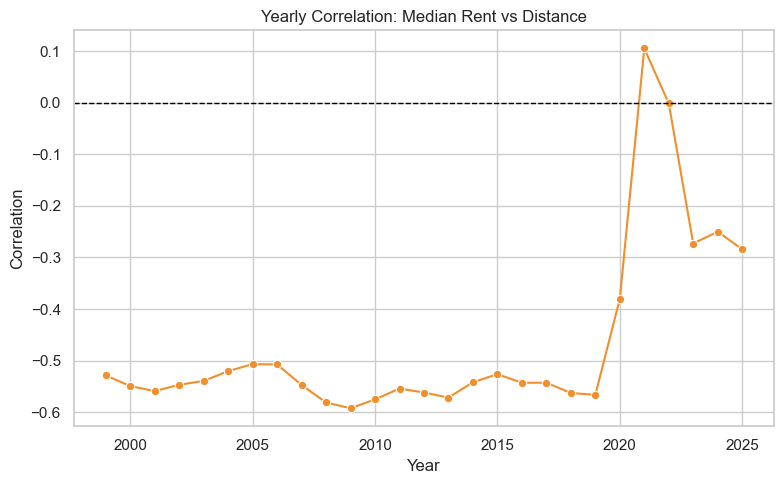

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# 5) Yearly correlation trend (rent vs distance)
year_corr_plot = (
    panel.dropna(subset=['median_rent', 'straight_line_km'])
         .groupby('year')
         .apply(lambda g: g['median_rent'].corr(g['straight_line_km']))
         .rename('corr_rent_distance')
)

plt.figure(figsize=(8, 5))
sns.lineplot(x=year_corr_plot.index, y=year_corr_plot.values, marker='o', color='#F28E2B')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Correlation')
plt.title('Yearly Correlation: Median Rent vs Distance')
plt.tight_layout()
plt.show()

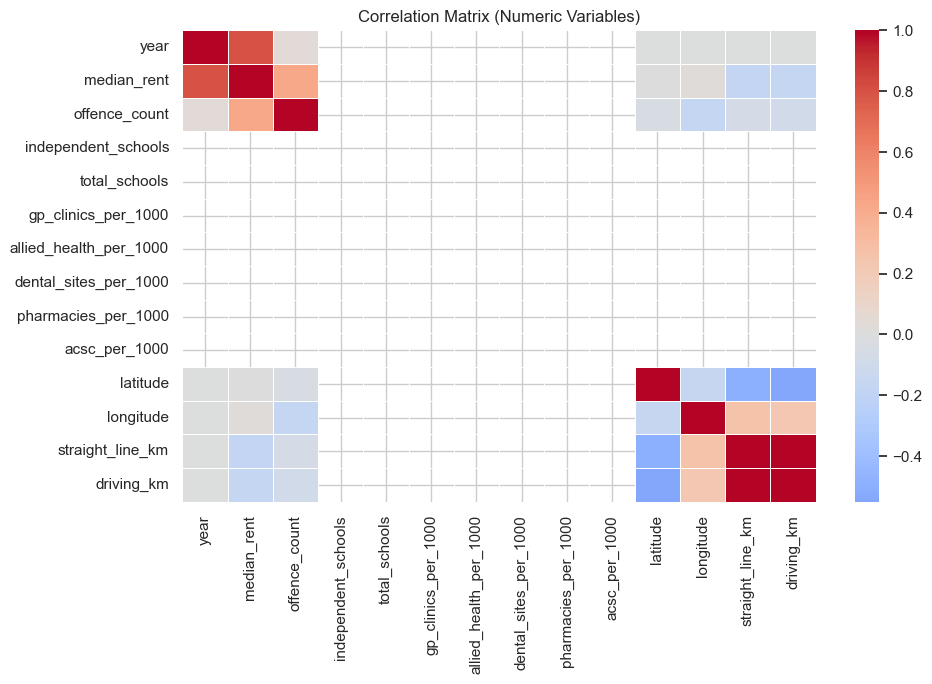

In [11]:
# 4) Correlation heatmap for numeric variables
corr = panel.select_dtypes(include='number').corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Variables)')
plt.tight_layout()
plt.show()

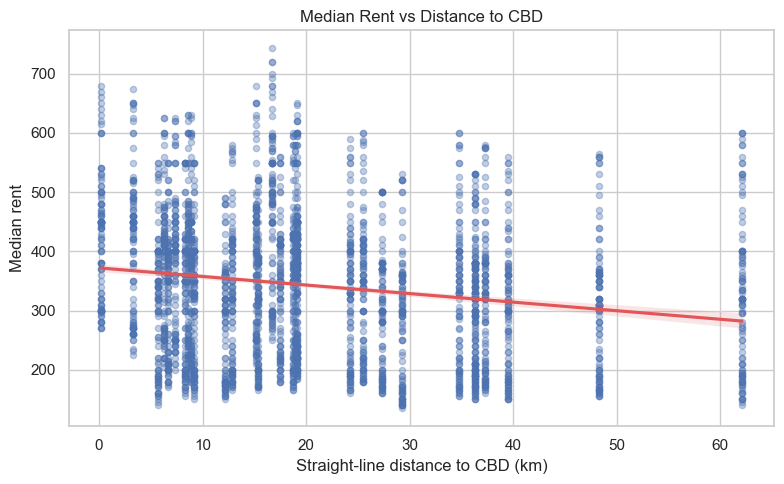

In [12]:
# 3) Rent-distance relationship
plot_df = panel[['median_rent', 'straight_line_km']].dropna()
plt.figure(figsize=(8, 5))
sns.regplot(data=plot_df, x='straight_line_km', y='median_rent',
            scatter_kws={'alpha': 0.35, 's': 20}, line_kws={'color': '#E15759'})
plt.xlabel('Straight-line distance to CBD (km)')
plt.ylabel('Median rent')
plt.title('Median Rent vs Distance to CBD')
plt.tight_layout()
plt.show()

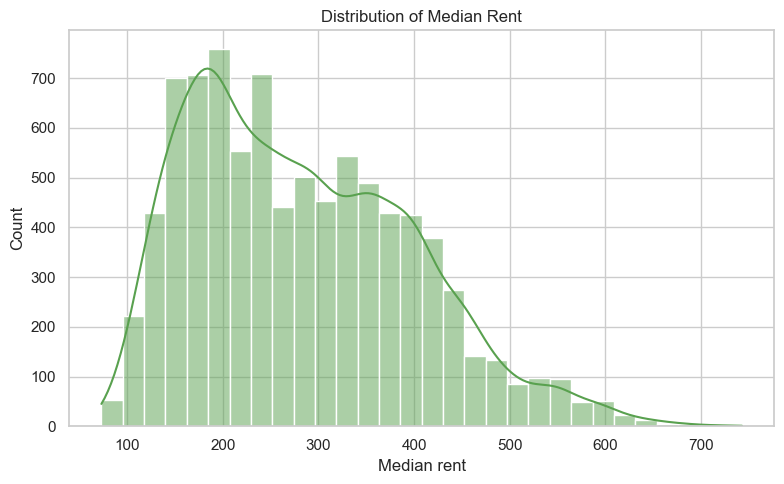

In [13]:
# 2) Distribution of median rent
plt.figure(figsize=(8, 5))
sns.histplot(panel['median_rent'].dropna(), bins=30, kde=True, color='#59A14F')
plt.xlabel('Median rent')
plt.title('Distribution of Median Rent')
plt.tight_layout()
plt.show()

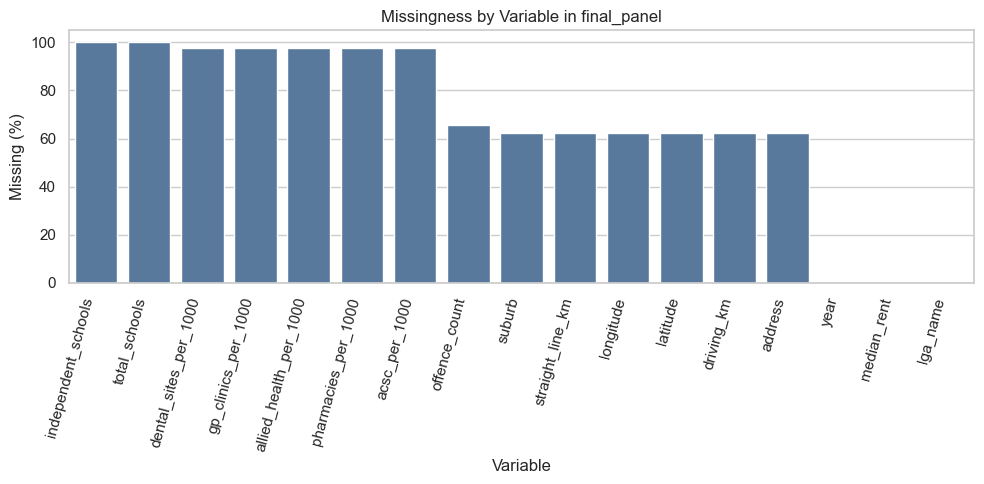

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# 1) Missingness bar chart
missing_pct = (panel.isna().mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, color='#4C78A8')
plt.xticks(rotation=75, ha='right')
plt.ylabel('Missing (%)')
plt.xlabel('Variable')
plt.title('Missingness by Variable in final_panel')
plt.tight_layout()
plt.show()

### What we learned
- The file behaves like a panel but is not strictly one row per LGA-year.
- Rent is complete and usable as the outcome variable.
- Distance and many controls are only available for a subset of LGAs.
- Schools variables are fully missing in the merged panel and are currently unusable.
- Several variables are right-skewed (especially offence_count and driving_km), motivating log transforms in later modelling.

## 2) Exploratory analysis of variable correlation

In [7]:
def safe_corr(x, y):
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return np.nan
    return x[m].corr(y[m])

print('Key first-order correlations')
print('corr(median_rent, straight_line_km):', round(safe_corr(panel['median_rent'], panel['straight_line_km']), 4))
print('corr(median_rent, driving_km):', round(safe_corr(panel['median_rent'], panel['driving_km']), 4))
print('corr(straight_line_km, driving_km):', round(safe_corr(panel['straight_line_km'], panel['driving_km']), 4))
print('corr(median_rent, offence_count):', round(safe_corr(panel['median_rent'], panel['offence_count']), 4))

Key first-order correlations
corr(median_rent, straight_line_km): -0.1769
corr(median_rent, driving_km): -0.1632
corr(straight_line_km, driving_km): 0.9904
corr(median_rent, offence_count): 0.4206


In [8]:
agg = panel.groupby(['lga_name','year'], as_index=False).agg({
    'median_rent': 'mean',
    'straight_line_km': 'mean',
    'driving_km': 'mean',
    'offence_count': 'mean'
})

print('corr after LGA-year aggregation:')
print('corr(median_rent, straight_line_km):', round(safe_corr(agg['median_rent'], agg['straight_line_km']), 4))

lga_means = agg.groupby('lga_name', as_index=False)[['median_rent','straight_line_km']].mean()
print('between-LGA correlation (LGA means):')
print('corr(mean_rent_by_LGA, mean_distance_by_LGA):', round(safe_corr(lga_means['median_rent'], lga_means['straight_line_km']), 4))

corr after LGA-year aggregation:
corr(median_rent, straight_line_km): -0.1731
between-LGA correlation (LGA means):
corr(mean_rent_by_LGA, mean_distance_by_LGA): -0.4926


In [9]:
year_corr = (
    agg.dropna(subset=['median_rent','straight_line_km'])
       .groupby('year')
       .apply(lambda g: g['median_rent'].corr(g['straight_line_km']))
       .rename('corr_rent_distance')
)
print('Year-by-year rent-distance correlation summary')
print(year_corr.describe()[['min','50%','max']])
year_corr.to_frame().head()

Year-by-year rent-distance correlation summary
min   -0.597733
50%   -0.546997
max    0.108017
Name: corr_rent_distance, dtype: float64


,corr_rent_distance
year,
1999,-0.531645
2000,-0.552054
2001,-0.562441
2002,-0.549226
2003,-0.541898


### What we learned
- A negative first-order effect exists: farther LGAs generally have lower median rent.
- The relationship is stronger when reducing repeated rows and focusing on between-LGA means.
- The distance-rent relationship changes over time, so pooled correlations can hide time structure.
- straight_line_km and driving_km are highly collinear, so they should not be used together in one model.
- The positive rent-offence correlation likely reflects urban-size confounding rather than direct causality.

## 3) What data cleaning changed

- LGA normalization removed CITY/SHIRE/COUNCIL text, but unresolved suffixes like (C)/(S)/(RC) still weaken merge quality.
- Rent cleaning preserved multiple observations per LGA-year (quarter information retained after extracting year).
- Distance data covers a metropolitan subset, creating structural missingness for non-covered LGAs.

### What we learned
- Cleaning succeeded for core rent and distance analysis, but key controls are still limited by merge and coverage issues.